# **Решение задач по курсу "Стохастический анализ"**
Работу выполнила студентка 315 группы, Алексеева Юлиана Максимовна.

## **Задание 1**
* Реализовать генератор схемы Бернулли с заданной вероятностью успеха $p$. На основе генератора схемы Бернулли построить датчик биномиального распределения.

* Реализовать генератор геометрического распределения; проверить для данного распределения свойство отсутствия памяти.

* Промоделировать игру в орлянку: бесконечную последовательность независимых испытаний Бернулли с бросанием "правильной" (честной, $p = 0.5$) монеты. Величина "выигрыша" $S_n$ определяется как сумма по $n$ испытаниям значений 1 и -1 в зависимости от выпавшей стороны монеты. Проиллюстрировать в виде ломаной поведение нормированной суммы $Y(i) = \frac{S_i}{\sqrt{n}}$ как функцию от номера испытания $i$ для отдельно взятой траектории. Дать теоретическую оценку для значения $Y(n)$ при $n \to \infty$.



---


**Определение.** Схемой Бернулли с заданной вероятностью успеха $p$ называется эксперимент, состоящий из серии испытаний, удовлетворяющих следующим свойствам:
1. Отсутствие взаимного влияния;
2. Воспроизводимость испытаний (испытания производятся в сходных условиях);
3. Существует признак, который реализуется (“успех” с вероятностью $p$) или не
реализуется (“неуспех” с вероятностью $q = (1-p)$) в испытании. Признак может
быть отнесен к любому из испытаний (в силу их однородности).

Случайную величину, имеющую распределение Бернулли, $Y \sim Ber(p)$, генерируем следующим образом: разыгрываем случайную величину $X \sim U[0, 1]$. При $X \leqslant p$ полагаем $Y = 1$, иначе $Y = 0$.

**Определение.** Случайная величина $X$ имеет биномиальное распределение с параметрами $n$ и $p$, $X \sim Bi(n, p)$, если
$\mathbb{P}(X = k) = C_n^k p^k (1-p)^{n-k}, \quad k \in \mathbb{N} \cup \{0\}.$

Случайную величину $X$ обычно интерпретируют как число успехов в серии из $n$ одинаковых независимых испытаний Бернулли с вероятностью успеха $p$ в каждом из них.
Значит, $X = \sum\limits_{k = 1}^{n}Y_k,$ где $X \sim Bi(n, p), Y \sim Ber(p)$.


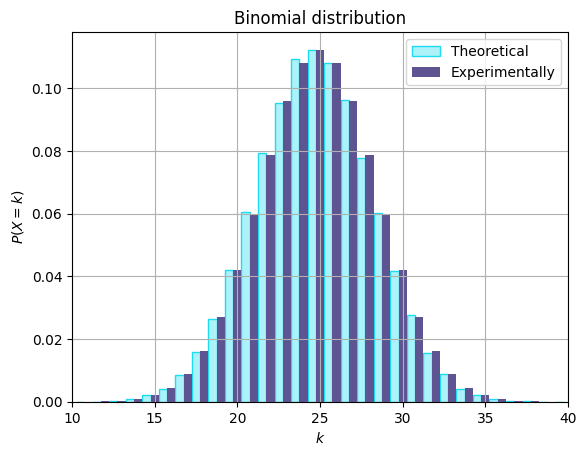

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
from scipy.special import comb

# Параметры
# p - заданная вероятность успеха,
# n - количество испытаний,
# count - количество выборок
p = 0.5
n = 50
count = 100000

# Генерируем  Бернулли
def ber(p, n, m):
    if not (0 <= p <= 1):
        print("Проверьте, правильно ли введены параметры.")
        return None
    return np.random.rand(n, m) < p

# Генерируем выборку из биномиального распределения
def bin_func(p, n, m):
    X = ber(p, n, m)
    # Суммируем по столбцам (axis = 0)
    return np.sum(X, axis = 0)

res = bin_func(p, n, count)
prob = np.bincount(res, minlength=n+1)/count

# Вычисляем значения по формуле
k = np.arange(0, n + 1)
res2 = comb(n, k) * (p ** k) * ((1 - p) ** (n - k))

# Проверяем правильность параметров
if res is None:
    print("Ошибка вычислений.")
    exit()

# Настройки графика
plt.figure
plt.grid(True)
plt.xlim(10, n-10)
plt.xlabel('$k$')
plt.ylabel('$P(X = k)$') # Added $ to indicate math mode for labels
plt.title('Binomial distribution')

# Вывод результатов (здесь гистограмму для результатов, полученных через формулу,
# сдвинула влево для удобства сравнения)
x = np.arange(0, n+1)
plt.bar(x-0.5, prob, width=0.5, color = '#ADF2F9',edgecolor = '#1ddbf0', label='Theoretical')
plt.bar(x, res2, width=0.5, color = '#5E5491', label='Experimentally')
plt.legend(fontsize=10)
plt.show()



---


**Определение.** Случайная величина $X$, равная количеству испытаний до появления
первого успеха в схеме Бернулли с параметром $p$, называется случайной величиной, имеющей геометрическое распределение с параметром $p (X \sim Geom(p))$.

Геометрическое распределение имеет вид: $\mathbb{P}(X = k) = p(1 - p)^k$.
Для моделирования случайной величины $X$ с геометрическим распределением будем
генерировать случайные величины $Y$ с распределением Бернулли и считать, сколько раз $Y$ приняла значение 0 до первого появления значения 1.

**Свойство.** Если $Y \sim Geom(p)$, то $\mathbb{P}(Y > m + n|Y > m) = \mathbb{P}(Y > n)$ для любых целых неотрицательных $n$ и $m$. Это свойство называется свойством "Отсутствия памяти" (другими словами, количество прошлых «неудач» не влияет на количество будущих «неудач»).


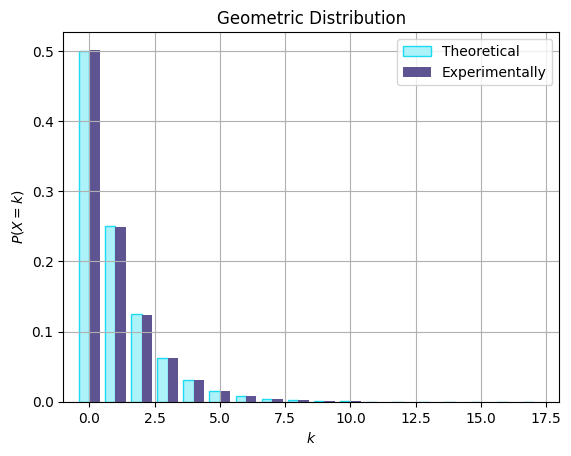

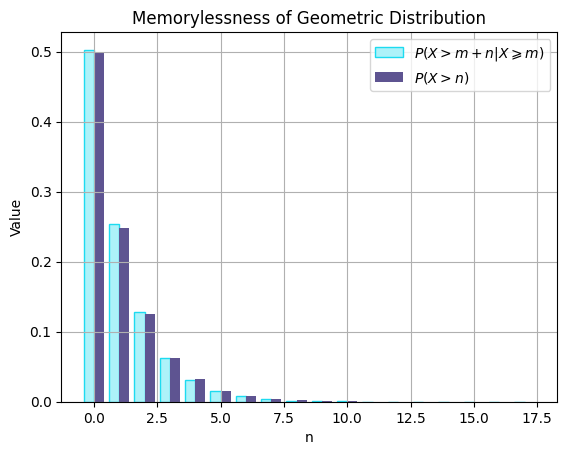

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import geom

# Параметры
# p - вероятность успеха,
# count - количество выборок
p = 0.5
count = 100000

# Генерируем выборку из геометрического распределения
def geom_func(p, m):
    if not (0 < p <= 1):
        print("Проверьте, правильно ли введены параметры.")
        return None

    # Генерируем случайные величины Y с распределением Бернулли
    results = []
    for i in range(m):
        trials = 0
        while True:
            # Успех
            if np.random.rand() < p:
                break
            trials += 1
        results.append(trials)
    return np.array(results)

# Генерация выборки из геометрического распределения
res = geom_func(p, count)
prob = np.bincount(res) / count

# Вычисляем теоретические значения по формуле геометрического распределения
k = np.arange(0, np.max(res) + 1)
res2 = p * (1 - p) ** k

# Проверяем правильность параметров
if res is None:
    print("Ошибка вычислений.")
    exit()

# Настройки графика
plt.figure()
plt.grid(True)
plt.xlim(-1, np.max(res) + 1)
plt.xlabel('$k$')
plt.ylabel('$P(X=k)$')  # Вероятности для X=k
plt.title('Geometric Distribution')

# Вывод результатов (гистограмма для экспериментальных данных и теоретических значений)
x = np.arange(0, len(prob))
plt.bar(x - 0.2, res2, width=0.4, color='#ADF2F9',edgecolor = '#1ddbf0', label='Theoretical')
plt.bar(x + 0.2, prob, width=0.4, color='#5E5491', label='Experimentally')
plt.legend(fontsize=10)
plt.show()

################################################################################
# Проверяем свойство "отсутствия памяти"
def check_memorylessness(res, m, n):
    # Когда Y >= m
    count_m = np.sum(res >= m)

    # Когда Y > n
    count_n = np.sum(res > n)

    # Когда Y > m + n
    count_mn = np.sum(res > (m + n))

    # Подсчитываем вероятности
    prob_n = count_n / count

    if count_m > 0:
        prob_mn_given_m = count_mn / count_m
    else:
        prob_mn_given_m = 0

    return prob_mn_given_m, prob_n

max_res = np.max(res) if len(res) > 0 else 30
n_values = np.arange(0, max_res + 1)
m = 3
prob_memorylessness = np.zeros(len(n_values))
prob_direct = np.zeros(len(n_values))

# Проверяем свойство отсутствия памяти
for i, j in enumerate(n_values):
    prob_memorylessness[i], prob_direct[i] = check_memorylessness(res, m, j)

# Настроиваем график для визуализации результатов
plt.figure()
plt.grid(True)
plt.xlabel('n')
plt.ylabel('Value')
plt.title('Memorylessness of Geometric Distribution')

# Выводим результаты
plt.bar(n_values - 0.2, prob_memorylessness, width=0.4, color='#ADF2F9',edgecolor = '#1ddbf0', label='$P(X > m+n | X \geqslant m)$')
plt.bar(n_values + 0.2, prob_direct, width=0.4, color='#5E5491', label='$P(X > n)$')
plt.legend()
plt.show()



---



**Игра в орлянку.**


Смоделируем последовательность случайных величин $X_1, X_2, \dots$, где

\begin{equation}
    X_n = \begin{cases}
        1, & \xi \in [0; 0.5) \\
        -1, & \xi \in [0.5; 1]
    \end{cases},
\end{equation}

где $\xi \sim U(0, 1)$. Тогда

\begin{equation}
    Y(i) = \frac{X_1 + X_2 + \dots + X_i}{\sqrt{n}}, \text{ где } i = \overline{1, n}.
\end{equation}

**Центральная предельная теорема.**
Пусть $X_1, \dots, X_n, \dots$ есть бесконечная последовательность независимых одинаково распределенных случайных величин, имеющих конечное математическое ожидание $\mu$ и дисперсию $\sigma^2$, соответственно. Пусть также
\begin{equation}
    S_n = \sum_{i=1}^{n} X_i.
\end{equation}

Тогда

\begin{equation}
    \frac{S_n - n\mu}{\sigma \sqrt{n}} \xrightarrow{d} N(0, 1) \text{ при } n \rightarrow \infty,
\end{equation}

где $N(0, 1)$ – нормальное распределение с нулевым математическим ожиданием и стандартным отклонением, равным единице.

В нашем случае:
$\mu = 0, \sigma = 1 \implies Y(n) = \frac{S_n}{\sqrt{n}} ⟶ N(0,1),$ при $n ⟶ \infty$.

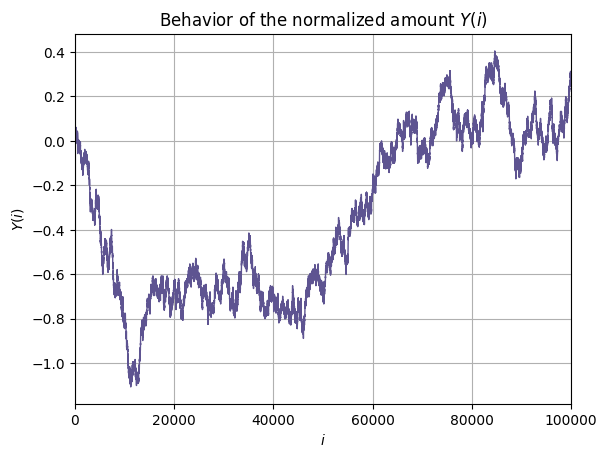

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

def ber(p, n, m):
    if p < 0 or p > 1:
        print("Проверьте, правильно ли введены параметры.")
        return None
    return np.random.rand(n, m) < p

# n - количество испытаний для каждой траектории
# m - количество траекторий (можно сделать больше 1)
# p - вероятность выпадения "орла"
n = 100000
m = 1
p = 0.5

# Генерируем результаты бросков монеты: 1 для "орла", -1 для "решки"
X = 2 * ber(p, n, m) - 1

# Считаем нормированную сумма для каждой траектории
Y = np.cumsum(X, axis=0) / np.sqrt(n)

# Визуализацируем результат
plt.figure()
x_lin = np.linspace(0, n, len(Y))
if m == 1:
    plt.plot(x_lin, Y, color = '#5E5491', label=f'Trajectory {i+1}', linewidth=1)
else:
    for i in range(m):
        plt.plot(x_lin, Y, label=f'Trajectory {i+1}', linewidth=1)
plt.title('Behavior of the normalized amount $Y(i)$')
plt.xlabel('$i$')
plt.ylabel('$Y(i)$')
plt.xlim(0, n)
plt.grid(True)
plt.show()

# **Задание 2**

*   Построить датчик сингулярного распределения, имеющий в качестве функции
распределения канторову лестницу. С помощью критерия Колмогорова убедиться в корректности работы датчика.
*   Для канторовых случайных величин с помощью критерия Смирнова проверить
свойство симметричности относительно $\frac{1}{2}$
($X$ и $1 − X$ распределены одинаково)
и свойство самоподобия относительно деления на 3 (условное распределение $Y$
при условии $Y \in [0, \frac{1}{3}]$ совпадает с распределением $\frac{Y}{3}$
).
*   Рассчитать значения математического ожидания и дисперсии для данного распределения. Сравнить теоретические значения с эмпирическими (для различных объемов выборок), проиллюстрировать сходимость эмпирических значений
к теоретическим.







---

**Определение.** Распределение называется сингулярным, если оно сосредоточено на континуальном множестве с нулевой мерой Лебега.

При построении канторова множества $F$ на отрезке $[0,1]$ мы выбрасываем из него интервалы $(\frac{1}{3}, \frac{2}{3}), (\frac{1}{9}, \frac{2}{9}), (\frac{7}{9}, \frac{8}{9}), ...$ В итоге получаем замкнутое множество $F$ (как пересечение замкнутых). Оно получается из отрезка $[0,1]$ выбрасыванием счетного числа интервалов. Отметим, что в канторовом множестве лежат только те точки, в записи которых в троичной системе счисления нет единиц. Таким образом, канторова лестница $F(X)$ действует на такие точки по правилу:
$$F(\{a_1, a_2, ..., a_n, ...\}_3) = \{a_1, a_2, ..., a_n, ...\}_2,$$
где $a_i$ равно 0 или 2.

Поэтому будем генерировать элементы данного множества следующим образом:
$$X = \sum\limits_{k=1}^{\infty}\dfrac{2\xi_k}{3^k}, \text{где } \xi_k \sim Ber(0.5).$$

Суммирование идет до бесконечности. При построении будем суммировать до некоторого разряда $n\in \mathbb{N}$.

Для проверки корректности работы датчика предлагается воспользоваться критерием Колмогорова. Будем считать максимальное по модулю отклонение эмпирической функции распределения от теоретической в точках выборки. Обозначим это число через $D_n$. Для проверки простой гипотезы $H_0$ о соответствии выборки известному закону распределения с заданным уровнем значимости $α$ рассчитаем p-value по статистике $\sqrt{n}D_n$, то есть найдем значение функции распределения Колмогорова в заданной точке. Для этого используем следующее представление для функции распределения Колмогорова:
$$F_K(x) = 1+2\sum\limits_{k=1}^{\infty}(-1)^ke^{-2k^2x^2}.$$
Гипотеза принимается, если $p=1-F_K(\sqrt{n}D_n)$ превышает заданный уровень значимости $\alpha$.

**Теорема Колмогорова.** Пусть $X_1, ..., X_n, ...~-~$бесконечная выборка из распределения, задаваемого непрерывной функцией распределения $F(x)$. Пусть $F_n(x)~-~$выборочная функция распределения, построенная на первых $n$ элементах выборки. Тогда $$\sqrt{n}\sup\limits_{x\in\mathbb{R}}|F_n(x)-F(x)|⟶K$$
по распределению при $n⟶∞$, где $K~-~$случайная величина, имеющая распределение Колмогорова.


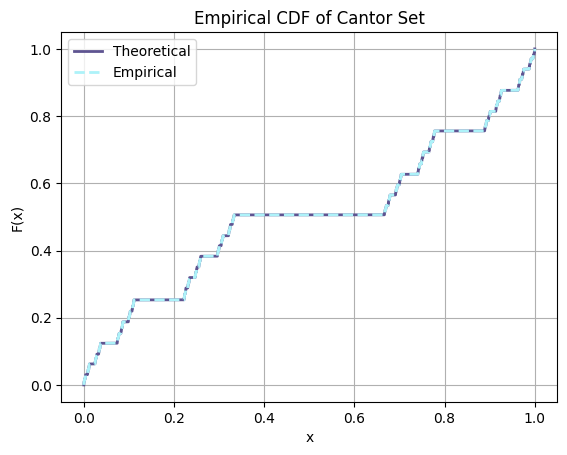

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

def ber(p, n, m):
    if p < 0 or p > 1:
        raise ValueError("Check if the parameters are entered correctly.")
    return np.random.rand(n, m) < p

def cantor(n, m, eps):
    bern = ber(0.5, n, m)
    deg = np.arange(1, m+1)
    x = 2 * np.sum(bern/(3.0 ** deg), axis=1)
    F = np.sum(bern/ (2.0 ** deg), axis=1)

    return x, F

# Параметры
n = 10000
eps= 1e-20
m = int(round(-np.log(eps) / np.log(9)))

# Генерируем данных Cantor
x_empirical, F_empirical = cantor(n, m, eps)

# Используем statsmodels для ECDF
ecdf = ECDF(x_empirical)
x_sorted = np.sort(x_empirical)

# Построение графика
plt.step(ecdf.x, ecdf.y, color='#5E5491', label='Theoretical', where='post', linewidth=2)
plt.step(x_sorted, np.arange(1, n + 1) / n, color='#ADF2F9', label='Empirical', where='post', linewidth=2, linestyle='--')
plt.grid()
plt.xlabel('x')
plt.ylabel('F(x)')
plt.legend()
plt.title('Empirical CDF of Cantor Set')
plt.show()

In [81]:
import numpy as np

def kolmcdf(x, k):
    Sum = 0
    for i in range(1, k + 1):
        Sum += (-1)**i * np.exp(-2 * (i**2) * (x**2))
    return 1 + 2 * Sum

# Параметры
hh = 1000
alpha = 0.05
n_values = [1000, 10000]
hh = [1000, 10000]
k = 1000
prin = 0
neprin = 0
results = {}

for n in n_values:
    for h in hh:
        for _ in range(1, h):
            x_empirical, F_empirical = cantor(n, m, eps)

            # Сортируем данные
            x_sorted = np.sort(x_empirical)

            # Эмпирическая функция распределения
            F_empirical_sorted = F_empirical[np.argsort(x_empirical)]
            F_k = np.arange(1, len(F_empirical) + 1)
            F_emp_1 = F_k / len(F_empirical)             # 1/n, 2/n, ...
            F_emp_2 = (F_k - 1) / (len(F_empirical) - 1) # (k-1)/(n-1), ...

            # Максимальное отклонение
            D_n = max(max(abs(F_emp_1 - F_empirical_sorted)), max(abs(F_emp_2 - F_empirical_sorted)))
            p_value = 1 - kolmcdf(np.sqrt(n) * D_n, k)
            if p_value > alpha:
                prin += 1
            else:
                neprin += 1
        total_tests = prin + neprin
        if total_tests > 0:
            percentage_acceptance = (100 * prin / total_tests)
        else:
            percentage_acceptance = 0

        results[(n, h)] = percentage_acceptance

# Выводим результаты
for (n, h), percentage in results.items():
    print(f'Объем выборки: {n}, кол-во итераций: {h}: Процент принятых гипотез: {percentage:.2f}%')

Объем выборки: 1000, кол-во итераций: 1000: Процент принятых гипотез: 96.70%
Объем выборки: 1000, кол-во итераций: 10000: Процент принятых гипотез: 95.51%
Объем выборки: 10000, кол-во итераций: 1000: Процент принятых гипотез: 95.52%
Объем выборки: 10000, кол-во итераций: 10000: Процент принятых гипотез: 95.29%




---


Проверим свойство симметричности относительно $\frac{1}{2}$ случайных величин $X$ и $1-X$. Рассмотрим случайную величину $1-X$:
$$1-X = 1-\sum\limits_{k=1}^{\infty}\dfrac{2\xi_k}{3^k} = \sum\limits_{k=1}^{\infty}\dfrac{2}{3^k}-\sum\limits_{k=1}^{\infty}\dfrac{2\xi_k}{3^k} = \sum\limits_{k=1}^{\infty}\dfrac{2(1-\xi_k)}{3^k} = \sum\limits_{k=1}^{\infty}\dfrac{2\eta_k}{3^k}.$$
Понятно, что $\eta\sim Bern(0.5),$ поэтому $X$ и $1-X$ распределены одинаково.

Проверим свойство самоподобия. Рассмотрим условное распределение $X$ при условии $X\in [0, \frac{1}{3}]$. Из построения случаной величины $X$ видно, что $X\in [0, \frac{1}{3}] ⇔ \xi_1 = 0.$ Если $X\in [0, \frac{1}{3}]$, то
$$X = \sum\limits_{k=2}^{\infty}\dfrac{2\xi_k}{3^k} = \sum\limits_{k=1}^{\infty}\dfrac{2\xi_{k+1}}{3^{k+1}} = \dfrac{1}{3}\sum\limits_{k=1}^{\infty}\dfrac{2\xi_k}{3^k} = \dfrac{1}{3}X.$$
Проверим упомянутые свойства с помощью критерия Смирнова. Найдем максимум поточечной разности двух эмпирических функций распределения. Обозначив полученное значение через $D_{nm}$, где $n, m~-~$длины выборок, и посчитав p-value по статистике $\sqrt{\frac{nm}{n+m}}D_{nm}$ для заданного уровня значимости $α$ проверим гипотезу $H_0$ о том, что обе выборки соответствуют одинаковому закону распределения.


**Теорема Смирнова.** Пусть $F_n^1(x), F_m^2(x)~-~$эмпирические функции распределения с объемами выборок $n$ и $m$ соответственно случайной величины $\xi$. Тогда, если $F(x)\in C^1(\mathbb{R})$, то
$$\lim\limits_{n,m → +∞}\mathbb{P}\left(\sqrt{\frac{nm}{n+m}}D_{nm}\leqslant t\right) = K(t) = \sum\limits_{-\infty}^{+\infty}(-1)^je^{-2j^2t^2}, \forall t > 0,$$
где $D_{nm}=\sup\limits_{x\in\mathbb{R}}|F^1_n-F^2_m|.$

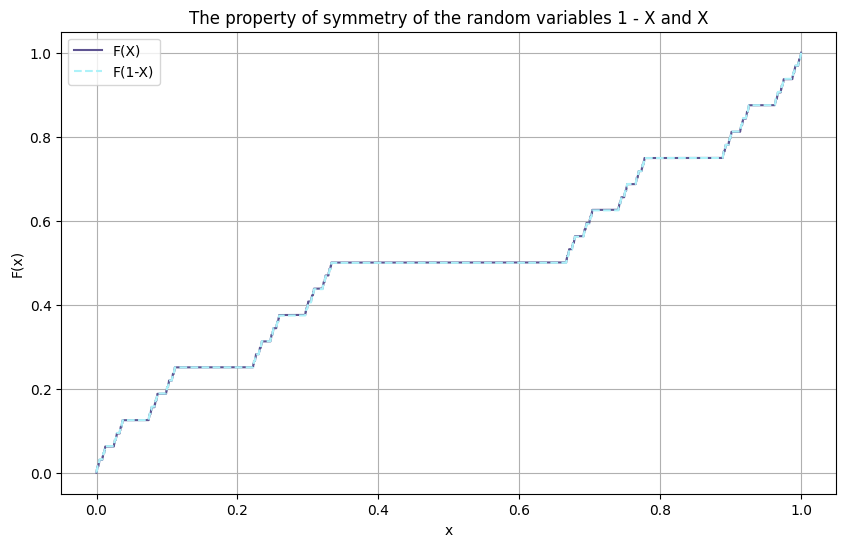

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры
alpha = 0.05
k = 1000
n = 100000
eps = 1e-20
m = int(round(-np.log(eps) / np.log(9)))

# Генерируем выборку
x, F = cantor(n, m, eps)
x_reflected = 1 - x

# Сортируем данные и задаем эмпирические функции через ECDF
x_sorted = np.sort(x)
x_reflected_sorted = np.sort(x_reflected)
ecdf = ECDF(x)
ecdf_reflected = ECDF(x_reflected)

# Строим график
plt.figure()
plt.step(x_sorted, ecdf(x_sorted), label='F(X)', color='#5E5491', where='post')
plt.step(x_reflected_sorted, ecdf_reflected(x_reflected_sorted), label='F(1-X)', color='#ADF2F9', where='post', linestyle = '--')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('F(x)')
plt.legend()
plt.title('The property of symmetry of the random variables 1 - X and X')
plt.show()

In [ ]:
import numpy as np
from scipy.stats import ks_2samp

# Параметры
alpha = 0.05
k = 1000
num_runs_list = [1000, 10000]   # Количество запусков
sample_sizes_list = [1000, 10000] # Объем выборки
eps = 1e-20

# Проценты принятых гипотез
results = {}

for num_runs in num_runs_list:
    for sample_size in sample_sizes_list:
        accepted_hypotheses = 0
        m = int(round(-np.log(eps) / np.log(9)))

        for _ in range(num_runs):
            # Генерируем выборки
            x1 = cantor(sample_size, m, eps)
            x2 = 1 - cantor(sample_size, m, eps)
            n_len = len(x1)
            m_len = len(x2)

            # Тест Колмогорова-Смирнова
            D_nm, _ = ks_2samp(x1, x2)

            # Вычисляем статистики теста
            D_nm_scaled = (np.sqrt((n_len * m_len) / (n_len + m_len))) * D_nm

            # Проверяем гипотезу
            p_value_kolmogorov = kolmcdf(D_nm_scaled, k)

            if p_value_kolmogorov > alpha:
                accepted_hypotheses += 1

        acceptance_rate = accepted_hypotheses / num_runs * 100
        results[(num_runs, sample_size)] = acceptance_rate

# Выводим результаты
for (num_runs, sample_size), acceptance_rate in results.items():
    print(f"Объем выборки: {sample_size}, кол-во итераций: {num_runs},  Процент принятых гипотез: {acceptance_rate:.2f}%")

Объем выборки: 1000, кол-во итераций: 1000,  Процент принятых гипотез: 93.60%
Объем выборки: 10000, кол-во итераций: 1000,  Процент принятых гипотез: 95.50%
Объем выборки: 1000, кол-во итераций: 10000,  Процент принятых гипотез: 93.19%
Объем выборки: 10000, кол-во итераций: 10000,  Процент принятых гипотез: 94.80%


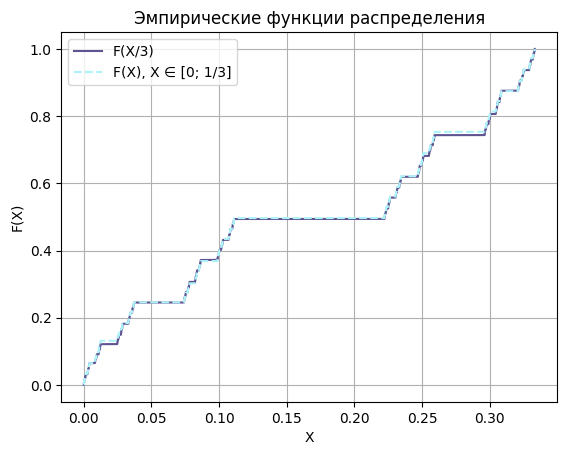

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Генерируем выборки из Канторова множества
def generate_cantor_samples(n, m, eps):
    bern = ber(0.5, n, m)
    deg = np.arange(1, m + 1)
    x = 2 * np.sum(bern/(3.0 ** deg), axis=1)
    x1 = x / 3
    t_1, F_1 = ecdf(x1)
    x2 = x[x < 1/3]
    t_2, F_2 = ecdf(x2)

    return t_1, F_1, t_2, F_2

# Параметры
alpha = 0.95
n = 10000
eps = 1e-13
m = int(-np.log(eps) / np.log(9))
x1, F1, x2, F2 = generate_cantor_samples(n, m,  eps)

# Визуализируем эмпирические функции распределения
plt.figure()
plt.step(x1, F1, label='F(X/3)', color='#5E5491', where='post')
plt.step(x2, F2, label='F(X), X ∈ [0; 1/3]', color='#ADF2F9', where='post', linestyle='--')
plt.grid()
plt.legend()
plt.xlabel('X')
plt.ylabel('F(X)')
plt.title('Эмпирические функции распределения')
plt.show()


In [ ]:
import numpy as np

# Параметры
alpha = 0.95
# Количество запусков
num_runs_list = [1000, 10000]
# Объем выборки
sample_sizes_list = [1000, 10000]
eps = 1e-13
k = 1000

# Проценты принятых гипотез
results = {}

for num_runs in num_runs_list:
    for sample_size in sample_sizes_list:
        accepted_hyp = 0

        for _ in range(num_runs):
            # Генерируем выборки
            x1, F1, x2, F2 = generate_cantor_samples(sample_size,m,  eps)
            n_len = len(x1)
            m_len = len(x2)

            # Тест Колмогорова-Смирнова
            D_nm, _ = ks_2samp(x1, x2)

            # Вычисляем статистику теста
            D_nm_scaled = (np.sqrt((n_len * m_len) / (n_len + m_len))) * D_nm

            # Проверяем гипотезу
            p_value_kolmogorov = kolmcdf(D_nm_scaled, k)
            if p_value_kolmogorov < alpha:
                accepted_hyp += 1

        acceptance_rate = accepted_hyp / num_runs * 100
        results[(num_runs, sample_size)] = acceptance_rate

# Выводим результаты
for (num_runs, sample_size), acceptance_rate in results.items():
    print(f"Объем выборки: {sample_size}, кол-во итераций: {num_runs}, Процент принятых гипотез: {acceptance_rate:.2f}%")

Объем выборки: 1000, кол-во итераций: 1000, Процент принятых гипотез: 97.10%
Объем выборки: 10000, кол-во итераций: 1000, Процент принятых гипотез: 96.00%
Объем выборки: 1000, кол-во итераций: 10000, Процент принятых гипотез: 95.97%
Объем выборки: 10000, кол-во итераций: 10000, Процент принятых гипотез: 96.31%




---

Вычислим значение математического ожидания:
$$\mathbb{E}X = \mathbb{E}\sum\limits_{k=1}^{\infty}\dfrac{2\xi_k}{3^k} = \sum\limits_{k=1}^{\infty}\dfrac{2\mathbb{E}\xi_k}{3^k} = \sum\limits_{k=1}^{\infty}\dfrac{1}{3^k} = \dfrac{1}{2},$$
где $\mathbb{E}\xi_k = \frac{1}{2}~-~$математическое ожидание случайной величины, имеющей распределение Бернулли с параметром $p = 0.5$.

Вычислим значение дисперсии:
$$\mathbb{D}X = \mathbb{D}\sum\limits_{k=1}^{\infty}\dfrac{2\xi_k}{3^k} =\{\mathbb{D}[aX] = a^2\mathbb{D}[X]\}= \sum\limits_{k=1}^{\infty}\dfrac{4\mathbb{D}\xi_k}{3^{2k}} = \sum\limits_{k=1}^{\infty}\dfrac{1}{3^{2k}} = \dfrac{1}{8},$$
где $\mathbb{D}\xi_k = pq = \frac{1}{4}~-~$математическое ожидание случайной величины, имеющее распределение Бернулли с параметром $p=0.5, q = 1-p = 0.5$.

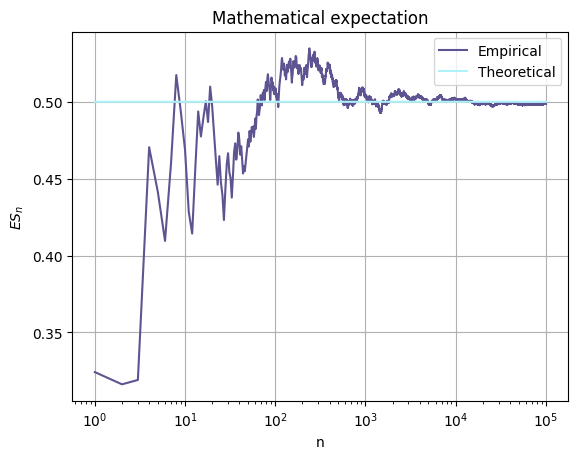

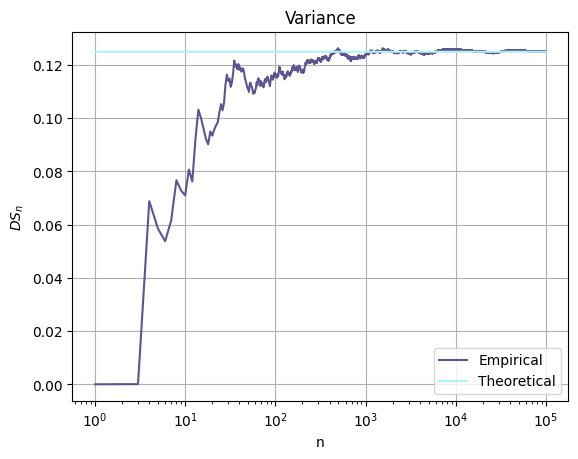

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

# Эмпирическая функция распределения
def ecdf(data):
    n = len(data)
    x = np.sort(data)
    F = np.arange(1, n + 1) / n
    return F, x

# Параметры
n = 100000
eps = 1e-20
m = int(round(-np.log(eps) / np.log(9)))

# Генерируем выборки
x_emp, F_emp = cantor(n, m, eps)
F_teor, x_teor = ecdf(x_emp)

iter_range = np.arange(1, len(x_emp) + 1)
EX_teor = np.mean(x_teor)
EX_emp = np.cumsum(x_emp) / iter_range

# Построение графика для мат. ожидания
plt.figure()
plt.semilogx(iter_range, EX_emp, label='Empirical', color = '#5E5491')
plt.semilogx(iter_range, 0.5 * np.ones(len(iter_range)), color='#ADF2F9', label='Theoretical')
plt.ylabel('$ES_n$')
plt.grid(True)
plt.xlabel('n')
plt.title('Mathematical expectation')
plt.legend()
plt.show()

DX_teor = np.var(x_teor)
DX_emp = np.cumsum(x_emp**2) / iter_range - EX_emp**2

# Построения графики для дисперсии
plt.figure()
plt.semilogx(iter_range, DX_emp, label='Empirical', color = '#5E5491')
plt.semilogx(iter_range, DX_teor * np.ones(len(iter_range)), color='#ADF2F9', label='Theoretical')
plt.grid(True)
plt.ylabel('$DS_n$')
plt.xlabel('n')
plt.title('Variance')
plt.legend()
plt.show()

# **Задание 3**


*   Построить датчик экспоненциального распределения. Проверить для данного
распределения свойство остутствия памяти.
*   Пусть $X_1, . . . , X_n$ — независимые экспоненциально распределенные случайные величины с параметрами $\lambda_1, . . . , \lambda_n$. Найти распределение случайной величины $Y = min(X_1, . . . , X_n)$.
*   На основе датчика экспоненциального распределения построить датчик пуассоновского распределения.
*   Построить датчик пуассоновского распределения как предел биномиального распределения. Убедиться в корректности построенного датчика при помощи критерия $\chi^2$ Пирсона.
*   Построить датчик стандартного нормального распределения методом моделирования случайных величин парами с переходом в полярные координаты (преобразование Бокса-Мюллера). Проверить при помощи t-критерия Стьюдента равенство математических ожиданий, а при помощи критерия Фишера — равенство
дисперсий.










---




**Определение.** Случайная величина $\xi$ имеет экспоненциальное распределение с параметром $\lambda>0$, если её функция распределения имеет вид:

$$F_{\xi}(x)=\left\{\begin{array}{ll}1-e^{-\lambda x},&x\geqslant 0,\\ 0,&x<0.\end{array}\right.$$

Обозначение: $X\sim Exp(\lambda)$.

**Теорема.** Пусть функция $F(x)$ непрерывна и монотонно возрастает на $R$, причём $\lim\limits_{x\to-\infty}F(x)=1$, $\lim\limits_{x\to+\infty}F(x)=0$, случайная величина $Y\sim U[0,1]$ распределение, то случайная величина $X=F^{-1}(Y)$ имеет функцию распределения $F_{X}(x)=F(x)$.

Применим эту теорему для моделирования датчика экспоненциального распределения на основе датчика равномерного.

$$F_{\xi}(x)=1-e^{-\lambda x}\implies F_{\xi}^{-1}(x)=-\frac{1}{\lambda}\ln(1-x).$$

Таким образом, если $Y\sim U[0,1]$, то
$$X=-\dfrac{1}{λ}ln(1-Y)$$
имеет экспоненциальное распределение с параметром $\lambda$.

Экспоненциальное распределение можно считать непрерывным аналогом геометрического распределения. Поэтому оно также обладает свойством отсутствия памяти. Т.e. $P(\eta > m + n|\eta \geq m) = P(\eta > n)$.

**Утверждение.**
Пусть $X_1, \ldots, X_n$ независимые случайные величины, и $X_i \sim \text{Exp}(\lambda_i)$.

Тогда $$Y = \min_{i=1, \ldots, n} (X_i) \sim \text{Exp} \left( \sum_{i=1}^n \lambda_i \right)$$.


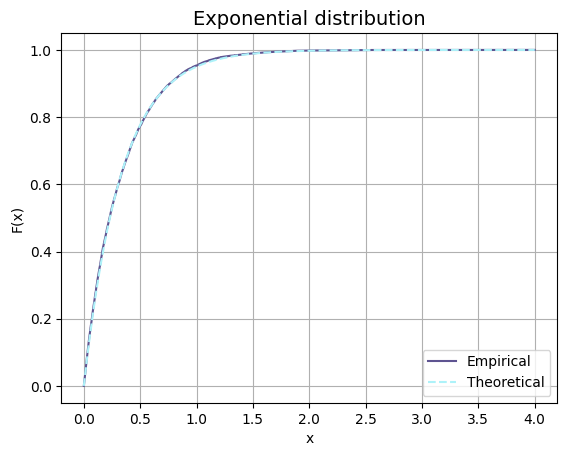

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Генерируем выборки из экспоненциального распределения
def expdist(lambda_param, n):
    if lambda_param == 0:
        raise ValueError("Lambda must not be zero.")
    y = np.random.rand(n)
    x = -np.log(1 - y) / lambda_param
    return x

# Параметры
lambda_param = 3
n = 10000

# Генерируем выборки
X_exp_0 = expdist(lambda_param, n)
X_exp_sorted = np.sort(X_exp_0)

# Эмпирическая функция распределения
F_exp = np.arange(1, n + 1) / n

# Строим график
plt.figure()
plt.plot(X_exp_sorted, F_exp, label='Empirical', color='#5E5491')

# Теоретическая функция распределения
x = np.linspace(np.min(X_exp_0), np.max(X_exp_0), n)
F_theoretical = 1 - np.exp(-lambda_param * x)
plt.plot(x, F_theoretical, label='Theoretical', color='#ADF2F9', linestyle = '--')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Exponential distribution')
plt.legend()
plt.grid()
plt.show()

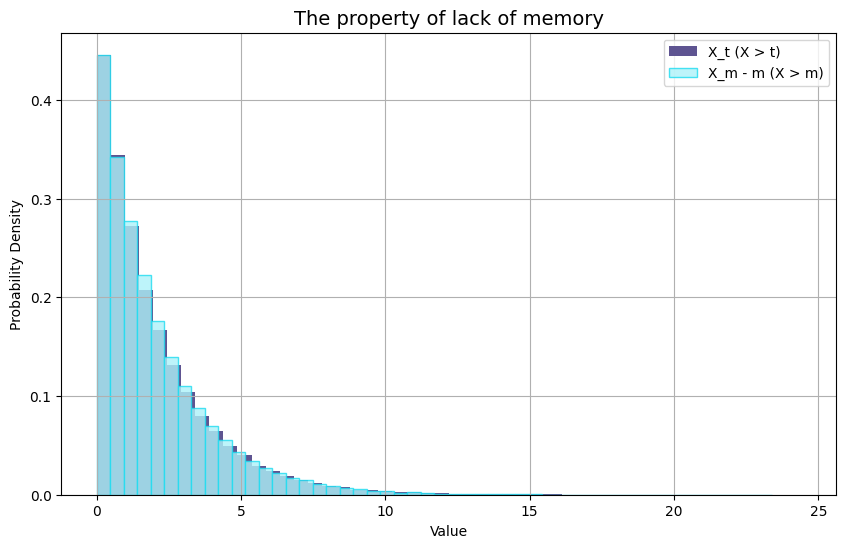

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры
n = int(1e5)
lambda_param = 0.5
t = 0
m = 1

# Генерируем выборки
X_exp_0 = expdist(lambda_param, n)

# Фильтрируем выборки
X_t = X_exp_0[X_exp_0 > t]
X_m = X_exp_0[X_exp_0 > m]

# Строим графики
plt.figure()
plt.hist(X_t, bins=50, density=True, alpha=1, label='X_t (X > t)', color='#5E5491')
plt.hist(X_m-m, bins=50, density=True, alpha=0.8, label='X_m - m (X > m)',edgecolor = '#1ddbf0', color='#ADF2F9')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.title('The property of lack of memory')
plt.legend()
plt.grid()
plt.show()

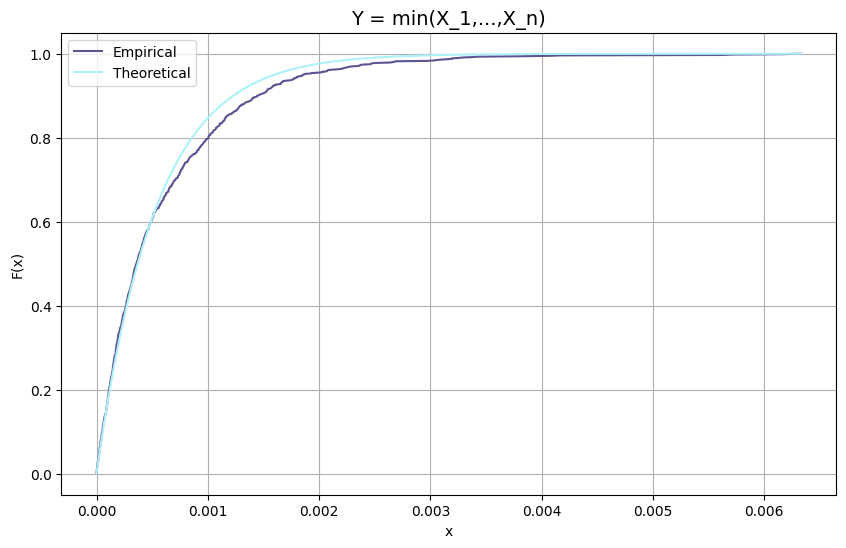

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Генерируем выборки минимального значения из n экспоненциальных распределений
def Y_min(n, lambda_min, lambda_max):
    lambdas = np.random.uniform(lambda_min, lambda_max, n)
    X = np.min(np.random.exponential(1 / lambdas[:, np.newaxis], size=(n, n)), axis=1)
    F_X = np.arange(1, n + 1) / n
    return np.sort(X), F_X

# Вычисляем теоретическую функцию распределения для Y = min(X_1,...,X_n)
def exprasp_teor(lamb, x):
    y = np.zeros_like(x)
    y[x >= 0] = 1 - np.exp(-lamb * x[x >= 0])
    return y

# Параметры
n = 1000
lambda_min = 0.75
lambda_max = 3

# Генерируем выборки
X, F_X = Y_min(n, lambda_min, lambda_max)

# Строим график эмпирической функции распределения
plt.figure()
plt.plot(X, F_X, label='Empirical', color='#5E5491')

# Вычисляем суммы лямбд и строим теоретическую функцию распределения
lambda_values = np.linspace(lambda_min, lambda_max, n)
Lamb_sum = np.sum(lambda_values)
plt.plot(X, exprasp_teor(Lamb_sum, X),label='Theoretical', color = '#ADF2F9')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Y = min(X_1,...,X_n)')
plt.legend()
plt.grid()
plt.show()



---


**Определение.**
Случайная величина $\xi$ имеет распределение Пуассона с параметром $\lambda > 0$, если

$$P(\xi = k) = \frac{\lambda^k}{k!}e^{-\lambda}, \quad k = 0, 1, 2, \ldots$$

Обозначение: $X \sim \text{Pois}(\lambda)$.

Для моделирования такой случайной величины воспользуемся следующей теоремой.

**Теорема.**
Пусть $\eta_1, \eta_2, \ldots, \eta_n, \ldots$ — независимые случайные величины, такие, что $X_i \sim \text{Exp}(\lambda)$, $i = 1, \infty$. Если

$$\xi = \max \left\{ n : \sum_{i=1}^n \eta_i < 1 \right\},$$

то случайная величина $\xi \sim \text{Pois}(\lambda)$. В случае, если $\eta_1 > 1$, то полагаем $\xi = 0$.

Согласно этому утверждению, можно моделировать нашу случайную величину следующим образом: будем генерировать случайные величины $\eta_i$ до тех пор, пока их сумма не превзойдёт единицу. Тогда случайная величина $\xi = i - 1$ будет иметь распределение Пуассона с параметром $\lambda$.

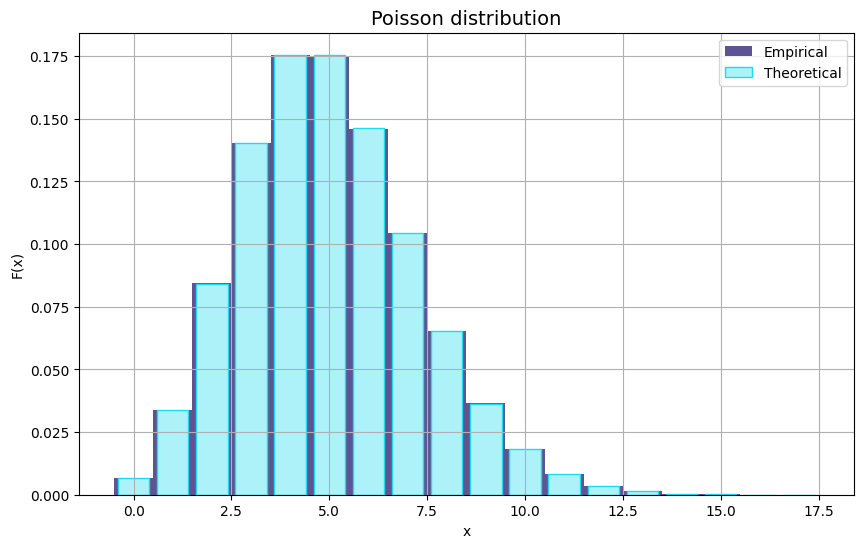

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Генерируем выборки из распределения Пуассона
def Poisson(lambda_param, n):
    X_Poisson = np.zeros(n)
    i = 0
    j = 1
    Sum_X = np.zeros(n)
    logic_2 = np.zeros(n, dtype=bool)
    while i < n:
        Y = np.random.uniform(0, 1, n)
        X = - (np.log(1 - Y)) / lambda_param
        Sum_X += X
        logic = Sum_X >= 1
        ind = np.where((logic_2.astype(int) - logic.astype(int)) == -1)[0]
        if ind.size > 0:
            i += len(ind)
            X_Poisson[ind] = j - 1
        j += 1
        logic_2 = logic
    return X_Poisson

# Параметры
n = int(1e6)
lambda_param = 5

# Генерируем выборки из распределения Пуассона
X_Poisson = Poisson(lambda_param, n)

# Строим гистограммы эмпирического распределения
plt.figure()
H1, bins, _ = plt.hist(X_Poisson, bins=np.arange(min(X_Poisson), max(X_Poisson) + 2) - 0.5,
                       density=True, color='#5E5491', label='Empirical')

# Вычисляем теоретическое распределение Пуассона
x = np.arange(min(X_Poisson), max(X_Poisson) + 1)
p = poisson.pmf(x, lambda_param)

# Строим теоретическую функцию распределения
plt.bar(x, p, width=0.8, color='#ADF2F9',edgecolor = '#1ddbf0', label='Theoretical')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Poisson distribution', fontsize=14)
plt.legend()
plt.grid()
plt.show()



---

**Теорема.**
Пусть случайная величина $X \sim B(n, p)$. Пусть $np = \lambda = \text{const}$.

Тогда при $n \longrightarrow \infty$

$$P(X = k) = C_n^k p^k (1 - p)^{n-k} \longrightarrow \frac{\lambda^k}{k!} e^{-\lambda}.$$

Критерий согласия Пирсона, или критерий согласия $\mathcal{X}^2$ наиболее часто употребляемый критерий для проверки гипотезы о принадлежности наблюдаемой выборки $x_1, x_2, \ldots, x_n$.


Объёмом $n$ некоторому теоретическому закону распределения $F(x, \theta)$.  
Используем критерий для проверки простой гипотезы вида:

$$H_0 : F_n(x) = \text{Pois}(x, \lambda).$$

Исследуемое распределение принимает только целые неотрицательные значения. Обозначим за $n_i$ количество элементов в выборке равных $i$. Теоретическая вероятность выпадения значения $i$ в распределении Пуассона:

$$p_i = \frac{\lambda^i}{i!} e^{-\lambda}.$$

Пусть $k$ — максимальное значение в выборке. Построим статистику критерия $\chi^2$ Пирсона:

$$\chi_n^2 = n \sum_{i=1}^k \left( \frac{n_i}{n} - p_i \right)^2.$$

Гипотеза о пуассоновском распределении построенной случайной величины будет верна, если вычисленное значение статистики $\chi_n^2$ не превосходит критического значения $\chi_{r, \alpha}^2$,  
где $r = k-1$, $\alpha$ — заданный уровень значимости.


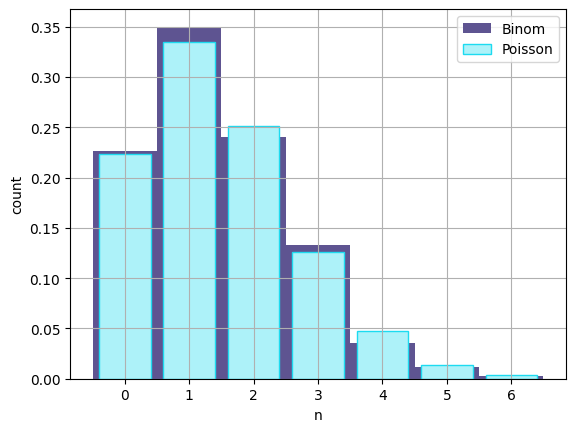

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, chi2

# Генерируем выборки из Бернулли
def Ber(p, n, m):
    if p < 0 or p > 1:
        raise ValueError("Check if the parameters are entered correctly.")
    return np.random.rand(n, m) < p

# Генерируем выборки из биномиального распределения
def Bin(p, n, m):
    X = Ber(p, n, m)
    return np.sum(X, axis=0)

# Параметры
p = 0.03
n = 50
m = 1000
lambda_param = n * p
k = n
r = k - 1
alpha = 0.05

# Генерируем выборки из биномиального распределения
Bin_Y = Bin(p, n, m)

# Строим гистограммы эмпирического распределения
plt.figure()
H, bins, _ = plt.hist(Bin_Y, bins=np.arange(min(Bin_Y), max(Bin_Y) + 2) - 0.5,
                       density=True, color='#5E5491', label='Binom')

# Вычисляем теоретическое распределение Пуассона
x = np.arange(min(Bin_Y), max(Bin_Y) + 1)
p_i_all = poisson.pmf(x, lambda_param)

# Строим теоретическую функцию распределения Пуассона
plt.bar(x, p_i_all, width=0.8, color='#ADF2F9', edgecolor = '#1ddbf0', label='Poisson')
plt.xlabel('n')
plt.ylabel('count')
plt.legend()
plt.grid()
plt.show()

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, chi2

# Подсчитываем частоты для биномиального распределения
v = np.zeros(len(x))
for i in range(len(x)):
    v[i] = np.sum(Bin_Y == i)

v_all = v / m

# Вычисляем статистики хи-квадрат
Xi_2 = m * np.sum(((v_all - p_i_all) ** 2) / p_i_all)

# Проверяем гипотезы с помощью критерия хи-квадрат
X_critical = chi2.ppf(1 - alpha, r)
if Xi_2 < X_critical:
    print('Гипотеза принимается.')
else:
    print('Гипотеза НЕ принимается.')

Гипотеза принимается.




---


Построим теперь случайную величину со стандартным нормальным распределением. Для этого рассмотрим случайные величины $\xi \sim \mathcal{N}(0,1)$, $\eta \sim \mathcal{N}(0,1)$. Совместная функция распределения имеет вид:

$$
P(\xi < x, \eta < y) = \frac{1}{2\pi} \int_{-\infty}^{x} \int_{-\infty}^{y} e^{-\frac{(\xi^2 +\eta^2)}{2}} d\xi d\eta = \frac{1}{2\pi} \iint_{\substack{r \cos \phi < x \\ r \sin \phi < y}} re^{-\frac{r^2}{2}} dr d\phi = \frac{1}{4\pi} \iint_{\substack{r \cos \phi < x \\ r \sin \phi < y}} e^{-\frac{\omega}{2}} d\omega d\phi.
$$

Подынтегральное выражение является произведением плотностей случайных величин

$$
\omega \sim \text{Exp}\left(\frac{1}{2}\right) \text{ и } \phi \sim U[0, 2\pi].
$$

Таким образом, совместное распределение случайных величин $\xi$, $\eta$ совпадает с совместным распределением $\{\sqrt{\omega} \cos \phi, \sqrt{\omega} \sin \phi\}$. Следовательно, мы можем построить стандартные нормальные случайные величины в следующем виде:

$$
\xi = \sqrt{\omega} \cos \phi, \quad \eta = \sqrt{\omega} \sin \phi,
$$

где $\omega \sim \text{Exp}\left(\frac{1}{2}\right)$ и $\phi \sim U[0, 2\pi]$.

Случайные величины $\xi$ и $\eta$ являются независимыми, так как их совместное распределение равно произведению маргинальных распределений:

$$
P(\xi < x, \eta < y) = \frac{1}{2\pi} \int_{-\infty}^{x} \int_{-\infty}^{y} e^{-\frac{x_1^2 + x_2^2}{2}} dx_1 dx_2 = \left(\int_{-\infty}^{x} \frac{1}{\sqrt{2\pi}} e^{-\frac{x_1^2}{2}} dx_1\right) \left(\int_{-\infty}^{y} \frac{1}{\sqrt{2\pi}} e^{-\frac{x_2^2}{2}} dx_2\right).
$$

Сформулируем критерий Стьюдента для проверки равенства математических ожиданий и проверим его на смоделированных случайных величинах $\xi$ и $\eta$.

**Критерий Стьюдента.**
Для проверки гипотезы $H_0: \mathbb{E}X = \mathbb{E}Y$ о равенстве математических ожиданий двух независимых нормальных случайных величин $X$ и $Y$ с неизвестными дисперсиями $\sigma_x^2$ и $\sigma_y^2$ используется статистика:

$$
T = \frac{\overline{x}^* - \overline{y}^*}{\sqrt{\frac{S_x^2}{n} + \frac{S_y^2}{m}}},
$$

где
\begin{align*}
\overline{x}^* &= \frac{1}{n} \sum_{i=1}^{n} x_i, \\
S_x^2 &= \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \overline{x}^*)^2, \\
\overline{y}^* &= \frac{1}{m} \sum_{i=1}^{m} y_i, \\
S_y^2 &= \frac{1}{m-1} \sum_{i=1}^{m} (y_i - \overline{y}^*)^2
\end{align*}
— выборочные оценки математических ожиданий и дисперсий. Здесь $n$ и $m$ — объемы.
В том случае, когда проверяемая гипотеза $H_0$ верна (то есть когда $\mathbb{E}X = \mathbb{E}Y$), статистика $T$ имеет распределение Стьюдента с числом степеней свободы:

$$
v = \frac{\left( \frac{S_x^2}{n} + \frac{S_y^2}{m} \right)^2}{\frac{\left( \frac{S_x^2}{n} \right)^2}{n-1} + \frac{\left( \frac{S_y^2}{m} \right)^2}{m-1}}.
$$

При превышении значения статистики по абсолютной величине критического значения данного распределения (при заданном уровне значимости) нулевая гипотеза отвергается, иначе принимается.

Результаты применения критерия к случайным величинам $\xi$ и $\eta$.


Далее сформулируем критерий Фишера равенства дисперсий и проверим его на смоделированных случайных величинах $\xi$ и $\eta$.

**Критерий Фишера.**
При проверке гипотезы $H_0: \sigma_x^2 = \sigma_y^2$ о равенстве дисперсий двух независимых нормальных случайных величин $X$ и $Y$ используется статистика:

$$
F = \frac{S_x^2}{S_y^2},
$$

называемая дисперсионным отношением, где
\begin{align*}
S_x^2 &= \frac{1}{n-1} \sum_{i=1}^n (x_i - \overline{x})^2, \\
S_y^2 &= \frac{1}{m-1} \sum_{i=1}^m (y_i - \overline{y})^2
\end{align*}
— несмещённые оценки дисперсий $\sigma_x^2$ и $\sigma_y^2$, найденные по независимым выборкам объёмов $n$ и $m$ соответственно.


В случае, когда гипотеза $H_0$ верна ($\sigma_x^2 = \sigma_y^2$), статистика $F$ имеет распределение Фишера-Снедекора (F-распределение) с $(n-1,m-1)$ степенями свободы.

Правило принятия решения:
1.  Если $F_{1-\alpha/2}(n-1,m-1) < F < F_{\alpha/2}(n-1,m-1)$, гипотеза $H_0$ принимается.
2.  В противном случае гипотеза $H_0$ отвергается.

Результаты применения критерия к случайным величинам $\xi$ и $\eta$.

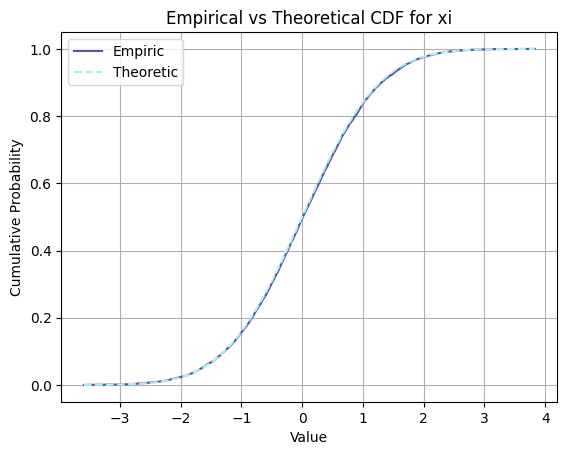

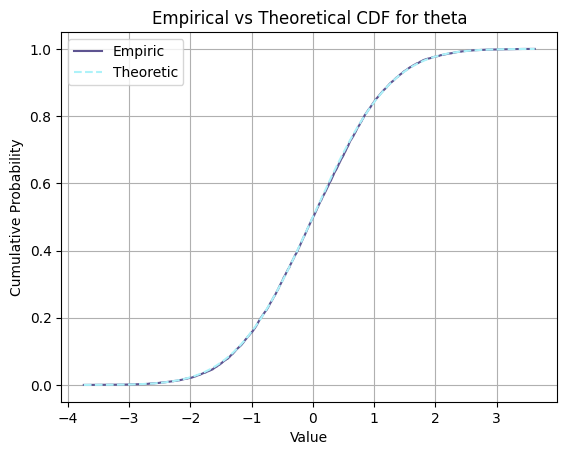

Гипотеза принимается.
Гипотеза принимается.


In [92]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t, f, expon

# Параметры
n = 10000
lambda_param = 0.5

# Генерируем случайные углы
fi = np.random.uniform(0, 2 * np.pi, n)

# Генерирум выборки из экспоненциального распределения
X_exp_0 = expon.rvs(scale=1/lambda_param, size=n)
omega = X_exp_0

# Статистики для нормального распределения (xi)
Stan_norm_rasp_xi = np.sqrt(omega) * np.cos(fi)

# Эмпирическая функция распределения
x_xi = np.sort(Stan_norm_rasp_xi)
y_xi = np.arange(1, n + 1) / n

# Строим графики
plt.figure()
plt.plot(x_xi, y_xi, color = '#5E5491', label='Empiric')
x = np.linspace(min(Stan_norm_rasp_xi), max(Stan_norm_rasp_xi), n)
y1 = norm.cdf(x, 0, 1)
plt.plot(x, y1, color='#ADF2F9', linestyle = '--', label='Theoretic')
plt.legend()
plt.title('Empirical vs Theoretical CDF for xi')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.grid()
plt.show()

# Статистики для нормального распределения (theta)
Stan_norm_rasp_teta = np.sqrt(omega) * np.sin(fi)

# Эмпирическая функция распределения
x_teta = np.sort(Stan_norm_rasp_teta)
y_teta = np.arange(1, n + 1) / n

# Строим графики
plt.figure()
plt.plot(x_teta, y_teta, color = '#5E5491', label='Empiric')
x2 = np.linspace(min(Stan_norm_rasp_teta), max(Stan_norm_rasp_teta), n)
y2 = norm.cdf(x2, 0, 1)
plt.plot(x2, y2,color='#ADF2F9',  linestyle = '--', label='Theoretic')
plt.legend()
plt.title('Empirical vs Theoretical CDF for theta')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.grid()
plt.show()

# Проверяем гипотезу с помощью t-критерия
def tStud(X, Y):
    n = len(X)
    X_line = np.mean(X)
    # Используем ddof=1 для несмещенной оценки дисперсии
    S_x = np.var(X, ddof=1)
    m = len(Y)
    Y_line = np.mean(Y)
    S_y = np.var(Y, ddof=1)
    t_statistic = (X_line - Y_line) / np.sqrt(S_x/n + S_y/m)
    return t_statistic

t_statistic = tStud(Stan_norm_rasp_xi, Stan_norm_rasp_teta)

alpha = 0.05
t_critical_low = t.ppf(alpha/2, n-1)
t_critical_high = t.ppf(1 - alpha/2, n-1)

if t_statistic >= t_critical_low and t_statistic <= t_critical_high:
    print('Гипотеза принимается.')
else:
    print('Гипотеза НЕ принимается.')

# Проверяем гипотезу с помощью F-критерия
def Fisher(X, Y):
    n = len(X)
    # Используем ddof=1 для несмещенной оценки дисперсии
    S_x =(np.var(X, ddof=1))
    m = len(Y)
    S_y =(np.var(Y, ddof=1))
    F_statistic = S_x / S_y
    return F_statistic

F_statistic = Fisher(Stan_norm_rasp_xi, Stan_norm_rasp_teta)

F_critical_low = f.ppf(alpha/2, n-1, n-1)
F_critical_high = f.ppf(1 - alpha/2, n-1, n-1)

if F_statistic >= F_critical_low and F_statistic <= F_critical_high:
    print('Гипотеза принимается.')
else:
    print('Гипотеза НЕ принимается.')

# **Задание 4**
*   Построить датчик распределения Коши.
*   На основе датчика распределения Коши с помощью метода фон Неймана построить датчик стандартного нормального распределения. При помощи графика normal probability plot убедиться в корректности построенного датчика и
обосновать наблюдаемую линейную зависимость.
*   Сравнить скорость моделирования стандартного нормального распределения в
задании 3 и в задании 4.







---


**Определение.**
Случайная величина $\xi$ имеет распределение Коши с параметрами сдвига $x_0$ и масштаба $\gamma > 0$, если её функция распределения имеет вид:

$$
F_\xi(x) = \frac{1}{\pi} \arctan \left( \frac{x - x_0}{\gamma} \right) + \frac{1}{2}.
$$

Обозначение: $\xi \sim C(x_0, \gamma)$.


Заметим, что функция распределения возрастает и имеет обратную функцию:

$$
F_\xi^{-1}(y) = x_0 + \gamma \tan\left( \pi \left( y - \frac{1}{2} \right) \right).
$$

Воспользовавшись теоремой 3.1, получим, что если $Y \sim U[0, 1]$, то $X = F_\xi^{-1}(Y)$ имеет распределение Коши.

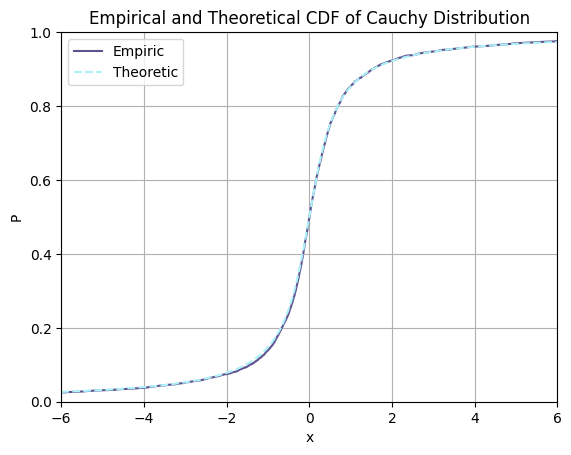

In [98]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры
n = 5000
a = -6
b = 6
x0 = 0
gamma = 0.5

# Функция для генерации выборки из распределения Коши
def cochi(x0, gamma, n):
    u = np.random.rand(n)
    x = x0 + gamma * np.tan(np.pi * (u - 0.5))
    return x

# Генерируем выборку
x1 = cochi(x0, gamma, n)

# Эмпирическая функция распределения
def ecdf(data):
    x_sorted = np.sort(data)
    y = np.arange(1, len(data) + 1) / len(data)
    return y, x_sorted

f, y = ecdf(x1)

# Строим
plt.figure()
plt.plot(y, f, label='Empiric', color='#5E5491')
plt.grid()

# Теоретическая функция распределения Коши
x = np.linspace(a, b, n)
F = 1/np.pi * np.arctan((x - x0) / gamma) + 0.5
plt.plot(x, F, label='Theoretic', color='#ADF2F9', linestyle = '--')
plt.xlabel('x')
plt.ylabel('P')
plt.axis([a, b, 0, 1])
plt.legend()
plt.title('Empirical and Theoretical CDF of Cauchy Distribution')
plt.show()



---

Опишем теперь суть метода фон Неймана. Имеются плотности двух распределений: $p_1(x)$ и $p_2(x)$. Проверяется существование такой константы $k$, что $kp_1(x) \geq p_2(x)$ для всех $x$. Если такое $k$ существует, то строится случайная величина $\xi$ по следующему алгоритму:

1. Генерируется случайный элемент $x$, соответствующий плотности $p_1(x)$.
    
2. Вычисляется $R = \dfrac{p_2(x)}{kp_1(x)}$.
    
3. Генерируется случайная величина $V(x) \sim \mathrm{Bern}(R)$, и если она равна 1, то значение $x$ возвращаем как результат генерации случайного элемента, имеющего плотность распределения $p_2(x)$; иначе процесс повторяется.

В нашем случае плотность распределения Коши имеет вид:

$$
p_1(x) = \frac{1}{\pi} \frac{\gamma}{(x - x_0)^2 + \gamma^2},
$$

Плотность стандартного нормального распределения:
$$
p_2(x) = \frac{1}{\sqrt{2\pi}} e^{-\frac{x^2}{2}}.
$$

Найдём параметры $x_0$ и $\gamma$, при которых достигается наибольшая скорость работы алгоритма фон Неймана, т.е. минимальное значение $k$:

$$
k^* = \min_{x_0, \gamma} \max_{x \in \mathbb{R}} \left( \frac{p_2(x)}{p_1(x)} \right).
$$

Рассмотрим два случая:

Случай 1: $x_0 = 0$
$$
k_0^* = \min_{\gamma} \max_{x \in \mathbb{R}} \frac{\sqrt{\pi}}{\gamma \sqrt{2}} (\gamma^2 + x^2) e^{-\frac{x^2}{2}}.
$$

Найдём максимум функции $f(x) = (\gamma^2 + x^2) e^{-\frac{x^2}{2}}$, вычислив нули производной:
$$
f'(x) = -e^{-\frac{x^2}{2}} x (x^2 + \gamma^2 - 2) = 0.
$$

Максимальное значение:
$$
k_0 = \min \left\{ \min_{|\gamma| > \sqrt{2}} \left(\gamma \sqrt{\frac{\pi}{2}}\right), \min_{|\gamma| < \sqrt{2}} \left( \frac{\sqrt{2\pi}}{\gamma} e^{-\frac{x^2}{2}} \right) \right\}
$$

Случай 2: $x_0 \neq 0$
$$
k^* = \min_{x_0, \gamma} \max_{x \in \mathbb{R}} \frac{\sqrt{\pi}}{\gamma \sqrt{2}} e^{-\frac{x^2}{2}} [\gamma^2 + (x - x_0)^2]
$$
$$
= \min_{x_0} \left\{ \min_{|\gamma| > \sqrt{2}} \max_{x} \left( \frac{\sqrt{\pi}}{\gamma \sqrt{2}} \left[ e^{-\frac{x^2}{2}} [\gamma^2 + (x - x_0)^2] \right] \right),
\min_{|\gamma| < \sqrt{2}} \max_{x} \left( \frac{\sqrt{\pi}}{\gamma \sqrt{2}} \left[ e^{-\frac{x^2}{2}} [\gamma^2 + (x - x_0)^2] \right] \right) \right\}
$$
$$
\geq \min_{x_0} \left\{ \min_{|\gamma| > \sqrt{2}} \left( \frac{\sqrt{\pi}}{\gamma \sqrt{2}} [x_0^2 + \gamma^2] \right), \min_{|\gamma| < \sqrt{2}} \left( \frac{\sqrt{\pi}}{\gamma \sqrt{2}} e^{-\frac{x^2}{2}} \left[ (|x_0| + \sqrt{2 - \gamma^2})^2 + \gamma^2 \right] \right) \right\}
$$
$$
> \min \left\{ \min_{|\gamma| > \sqrt{2}} \left(\gamma \sqrt{\frac{\pi}{2}}\right), \min_{|\gamma| < \sqrt{2}} \left( \frac{\sqrt{2\pi}}{\gamma} e^{-\frac{x^2}{2}} \right) \right\} = k_0^*
$$

Таким образом, получаем, что $k^* > k_0^*$ для всех $x_0 \neq 0$, что означает: наибольшая скорость работы алгоритма фон Неймана достигается при $x_0 = 0$.

$$
k^* = \min \left\{
    \min_{|\gamma| > \sqrt{2}} \left(\gamma \sqrt{\frac{\pi}{2}}\right),
    \min_{|\gamma| \leq \sqrt{2}} \left( \frac{\sqrt{2\pi}}{\gamma} e^{\frac{\gamma^2 - 2}{2}} \right)
\right\}
= \min \left\{
    \sqrt{\pi},
    \min_{|\gamma| \leq \sqrt{2}} \left( \frac{\sqrt{2\pi}}{\gamma} e^{\frac{\gamma^2 - 2}{2}} \right)
\right\}
$$

Исследуем функцию $f(\gamma) = \dfrac{\sqrt{2\pi}}{\gamma} e^{\frac{\gamma^2 - 2}{2}}$ на минимум. Вычислим её производную:

$$
f'(\gamma) = \sqrt{2\pi} e^{\frac{\gamma^2 - 2}{2}} \left( 1 - \frac{1}{\gamma^2} \right),
$$

Таким образом, функция $f(\gamma)$ достигает своего минимума
$$
\sqrt{\frac{2\pi}{e}} \quad \text{при } \gamma = 1 \in [-\sqrt{2}, \sqrt{2}].
$$
Следовательно,
$$
k^* = \min \left\{ \sqrt{\pi}, \sqrt{\frac{2\pi}{e}} \right\} = \sqrt{\frac{2\pi}{e}}.
$$

Максимальная скорость работы алгоритма фон Неймана достигается при параметрах $x_0 = 0$ и $\gamma = 1$.

Для теоретического обоснования метода моделирования фон Неймана воспользуемся следующим утверждением.

**Утверждение.**
Пусть $P$ и $Q$ — вероятностные меры, заданные на измеримом пространстве $(\mathcal{X}, \mathcal{A})$, причём $P(A) \leq kQ(A)$ для всех $A \in \mathcal{A}$ и некоторого $k \in \mathbb{R}$. Пусть $\nu$ — бернуллиевская случайная величина с параметром $p = \frac{dP}{kdQ}$. Тогда
$$
\mathbb{P}(X \in A \mid \nu = 1) = P(A).
$$

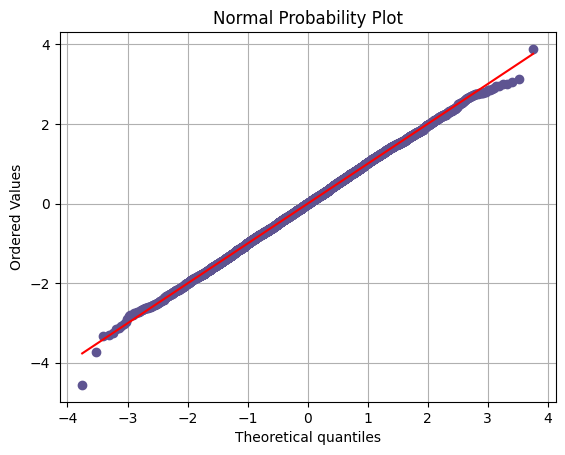

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

def mfn(n):
    b = np.zeros(n)
    i = 0
    # Нормальное распределение
    f2 = lambda x: 1 / (np.sqrt(2 * np.pi)) * np.exp(-x**2 / 2)
    # Распределение Коши
    f1 = lambda x: 1 / np.pi * (1 / (x**2 + 1))
    k = np.sqrt(2 * np.pi / np.exp(1))

    while i < n:
        x = cochi(0, 1, 1, 1)
        # Извлекаем скалярное значение из массива
        x = x.item()
        u = Ber(f2(x) / (k * f1(x)), 1, 1)
        if u == 1:
            b[i] = x
            i += 1
    return b

def cochi(x0, gamma, n, m):
    u = np.random.rand(n, m)
    return x0 + gamma * np.tan(np.pi * (u - 0.5))

# Генерируем данные
n = 8000
b = mfn(n)

# Строим вероятностный график
fig = plt.figure()
ax = fig.add_subplot(111)
stats.probplot(b, dist="norm", plot=ax)
line = ax.get_lines()[0]
line.set_color('#5E5491')
line.set_linewidth(2)
plt.title("Normal Probability Plot")
plt.grid(True)
plt.show()

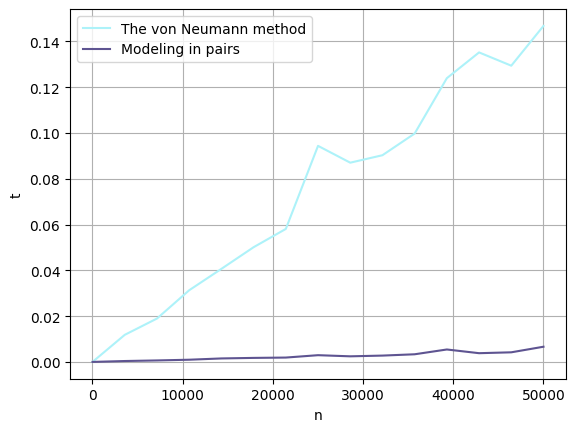

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import time

def normalp(n, m):
    psi = 2 * np.pi * np.random.rand(n, m)
    omega = expdist(1/2, n, m)
    ksi = np.sqrt(omega) * np.cos(psi)
    nu = np.sqrt(omega) * np.sin(psi)
    return ksi, nu

def expdist(lambda_, n, m):
    y = np.random.rand(n, m)
    if lambda_ != 0:
        x = -np.log(1 - y) / lambda_
    else:
        print('Error')
        x = np.array([])
    return x

# Параметры
M = 3
l = np.linspace(10, 5 * 10**4, 15)
k = 15
t1 = np.zeros(k)
t2 = np.zeros(k)

for j in range(k):
    n = int(round(l[j]))
    a = 0
    b = 0
    # Измеряем время для метода фон Неймана
    for _ in range(M):
        start = time.time()
        mfn(n)
        a += time.time() - start
    t1[j] = a / M
    # Измеряем время для моделирования парами
    for _ in range(M):
        start = time.time()
        normalp(1, n)
        b += time.time() - start
    t2[j] = b / M

# Строим график
plt.figure('Simulation time of the standard normal distribution')
plt.plot(np.round(l), t1/10, '#ADF2F9', label='The von Neumann method')
plt.plot(np.round(l), t2, '#5E5491', label='Modeling in pairs')
plt.grid(True)
plt.xlabel('n')
plt.ylabel('t')
plt.legend()
plt.show()

# **Задание 5**


*   Пусть $X_i ∼ \mathcal{N}(\mu, σ^2).$ Убедиться эмпирически в справедливости теоремы о законе больших чисел (ЗБЧ) и центральной предельной теоремы (ЦПТ): исследовать поведение суммы $S_n = \sum\limits_{i = 1}^nX_i$ и эмпирического распределения величины $$\sqrt{n}\dfrac{S_n}{n}-a.$$
*   Считая $\mu, \sigma$ неизвестными, построить доверительные интервалы для среднего и дисперсии по имеющейся выборке.
*   Пусть $X_i \sim K(a,b)~-~$имеет распределение Коши с параметром сдвига $а$ и масштаба $b$. Изучить эмпирически как ведут себя суммы $\frac{S_n}{n}$, объяснить результат и найти закон распределения данных сумм.







---

Пусть $X_i \sim \mathcal{N}(\mu, \sigma^2)$. Исследуем поведение суммы $\frac{S_n}{n}$ и эмпирического распределения величины
$$
\sqrt{n} \left( \frac{S_n}{n} - \mu \right).
$$

**Закон больших чисел.**
Пусть $X_1, X_2, \ldots$ — независимые одинаково распределённые случайные величины, $\mathbb{E}X_i = \mu$, $\forall i \in \mathbb{N}$, $|\mu| < \infty$, $S_n = X_1 + \ldots + X_n$. Тогда
$$
\frac{S_n}{n} \xrightarrow{\mathbb{P}} \mu \text{ при } n \to \infty,
$$
т.е.
$$
\forall \varepsilon > 0 \quad \mathbb{P} \left( \left| \frac{S_n}{n} - \mu \right| \geq \varepsilon \right) \xrightarrow{n \to \infty} 0.
$$

**Центральная предельная теорема.**
Пусть $X_1, X_2, \ldots$ — независимые одинаково распределённые случайные величины, $0 < \mathbb{E}X_i^2 < \infty$, $\forall i \in \mathbb{N}$, $S_n = X_1 + \ldots + X_n$. Тогда
$$
\mathbb{P} \left( \frac{S_n - \mathbb{E}S_n}{\sqrt{\mathbb{D}S_n}} \leq x \right) \xrightarrow{n \to \infty} \Phi(x), \quad x \in \mathbb{R},
$$
где $\Phi(x)$ — функция стандартного нормального распределения:
$$
\Phi(x) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{x} e^{-\frac{u^2}{2}} du.
$$

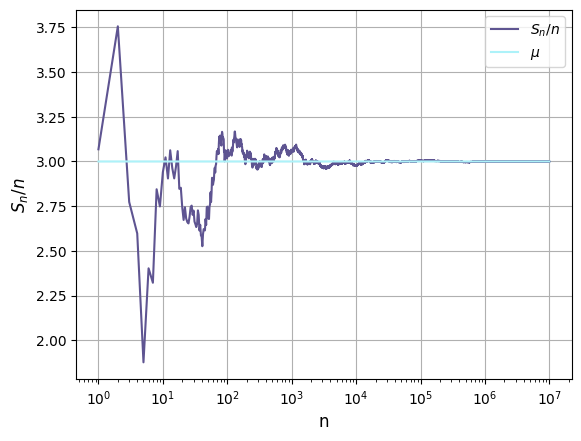

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры
mu = 3
sigma_sqr = 4
num = 10000000

# Генерируем данные
n = np.linspace(1, num, num)
random_numbers = np.random.normal(loc=mu, scale=np.sqrt(sigma_sqr), size=num)
sns = np.cumsum(random_numbers)

# Строим график
plt.figure('The law of large numbers for a normal distribution')
plt.semilogx(n, sns/n, '#5E5491', label='$S_n/n$')
plt.semilogx(n, [mu]*len(n), '#ADF2F9', label='$\mu$')
plt.grid(True)
plt.xlabel('n')
plt.ylabel('$S_n/n$')
plt.legend(['$S_n/n$', '$\mu$'])
plt.show()

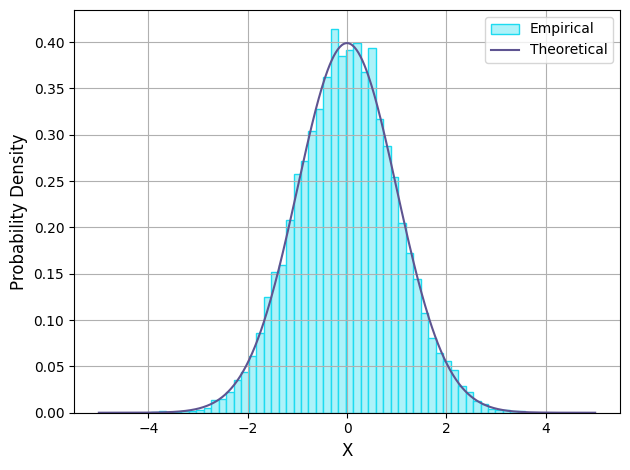

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def emp_rasp(mu, sigma_sqr, n):
    return np.sqrt(n) * (Sn_n(mu, sigma_sqr, n) - mu)

def Sn_n(mu, sigma_sqr, n):
    m = int(1e4)
    # Генерируем n x m нормальных случайных величин и суммируем по строкам
    s = np.sum(np.random.normal(loc=mu, scale=np.sqrt(sigma_sqr), size=(n, m)), axis=1)
    return s / m

def normal_formula(x):
    return norm.pdf(x)

# Параметры
mu = 0.5
sigma_sqr = 1
num = int(1e4)

# Генерируем эмпирические данные
empirs = emp_rasp(mu, sigma_sqr, num)

# Строим гистограммы
plt.figure('The central limit theorem for the normal distribution')
plt.hist(empirs, bins=50, density=True, color = '#ADF2F9', edgecolor = '#1ddbf0', label='Empirical')
x = np.linspace(-5, 5, 500)
plt.plot(x, normal_formula(x), '#5E5491', label='Theoretical')
plt.grid(True)
plt.xlabel('X')
plt.ylabel('Probability Density')
plt.legend()
plt.tight_layout()
plt.show()



---

Рассмотрим случайную величину $X \sim \mathcal{N}(\mu, \sigma^2)$. Пусть $x_1, x_2, \ldots, x_n$ — её реализации. Введём обозначения:


* Выборочное среднее:
$$
\bar{x} = \frac{1}{n} \sum_{i=1}^n x_i;
$$

* Выборочная дисперсия:
$$
s^2 = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})^2.
$$

Для параметров строятся следующие точные доверительные интервалы:

1. Для неизвестного среднего $\mu$ при неизвестной дисперсии $\sigma^2$:
$$
\bar{x} - \frac{s}{\sqrt{n}} t_\gamma < \mu < \bar{x} + \frac{s}{\sqrt{n}} t_\gamma,
$$
где $t_\gamma$ — критическая точка распределения Стьюдента с $n-1$ степенями свободы и уровнем значимости $\alpha = 1 - \gamma$;

2. Для неизвестной дисперсии:
$$
\frac{(n-1)s^2}{\chi_{\gamma/2, n-1}^2} < \sigma^2 < \frac{(n-1)s^2}{\chi_{1-\gamma/2, n-1}^2},
$$
где $\chi_{n-1}^2$ — критические точки $\chi^2$-распределения с $n-1$ степенями свободы.


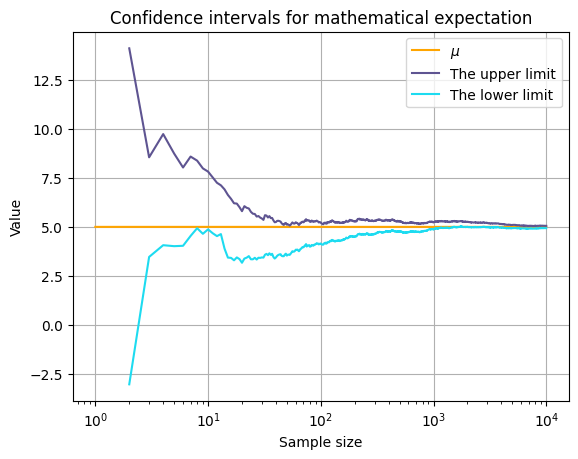

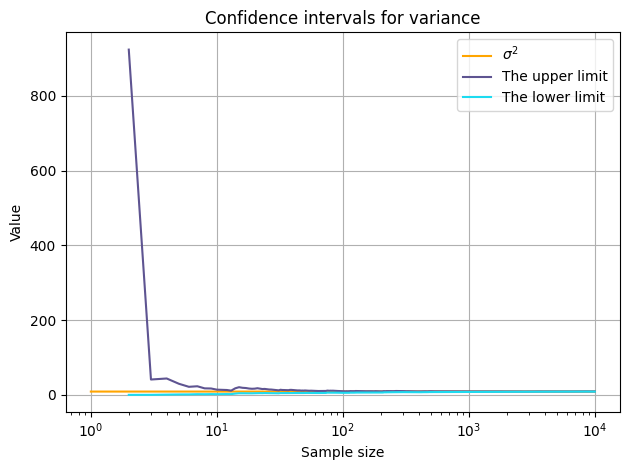

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, chi2

# Параметры
n = 10000
mu = 5
sigma = 3
alpha_1 = 0.05
alpha_2 = 0.95

# Генеруем случайные числа
np.random.seed(42)
X = np.random.normal(loc=mu, scale=sigma, size=n)

# Подготавливаем данные
grid = np.linspace(1, n, n)
# Выборочное среднее
EX = np.cumsum(X) / grid
# Выборочная дисперсия
DX = np.cumsum(X**2) / grid - EX**2

# Доверительные интервалы для мат. ожидания
t_crit = t.ppf(1 - alpha_1/2, np.arange(0, n))
a1 = EX + (np.sqrt(DX) / np.sqrt(grid)) * t_crit
b1 = EX - (np.sqrt(DX) / np.sqrt(grid)) * t_crit

# Строим графики для мат. ожидания
plt.figure()
plt.semilogx(grid, np.ones(n) * mu, 'orange', label='$\mu$')
plt.semilogx(grid, a1, '#5E5491', label='The upper limit')
plt.semilogx(grid, b1, '#1ddbf0', label='The lower limit')
plt.grid(True)
plt.legend()
plt.title('Confidence intervals for mathematical expectation', fontsize=12)
plt.xlabel('Sample size')
plt.ylabel('Value')

# Доверительные интервалы для дисперсии
xi1 = chi2.ppf((1 - alpha_2)/2, np.arange(0, n))
xi2 = chi2.ppf((1 + alpha_2)/2, np.arange(0, n))
a2 = (np.arange(0, n) * DX) / xi1
b2 = (np.arange(0, n) * DX) / xi2

# Строим графики для дисперсии
plt.figure()
plt.semilogx(grid, np.ones(n) * sigma**2, 'orange', label='$\sigma^2$')
plt.semilogx(grid, a2, '#5E5491', label='The upper limit')
plt.semilogx(grid, b2, '#1ddbf0', label='The lower limit')
plt.grid(True)
plt.legend()
plt.title('Confidence intervals for variance')
plt.xlabel('Sample size')
plt.ylabel('Value')
plt.show()



---

Пусть $X_i \sim C(a, b)$, $\forall i \in \mathbb{N}$.

Предела $\frac{S_n}{n}$ не существует, то есть закон больших чисел для распределения Коши не выполняется. Заметим, что это можно объяснить тем, что математическое ожидание данной случайной величины не существует, что нарушает одно из условий теоремы о ЗБЧ. Докажем, что математическое ожидание случайной величины $X \sim C(a, b)$ не является конечным:

$$
\mathbb{E}X = \frac{1}{\pi} \int_{-\infty}^{\infty} \frac{bx}{(x - a)^2 + b^2} dx = \frac{b}{2\pi} \ln\left((x - a)^2 + b^2\right) \bigg|_{-\infty}^{\infty} = \infty - \infty.
$$

Следовательно, эмпирический результат соответствует теории.

Напомним вид функции распределения Коши:

$$
F_X(x) = \frac{1}{\pi} \arctan \left( \frac{x - a}{b} \right) + \frac{1}{2}.$$

Из её вида вытекает следующая теорема:

**Теорема.**
Если $\xi_1 \sim C(a_1, b_1)$, $\xi_2 \sim C(a_2, b_2)$, то $\xi_1 + \xi_2 \sim C(a_1 + a_2, b_1 + b_2)$. Или, что то же самое,

$$
C(a_1, b_1) * C(a_2, b_2) = C(a_1 + a_2, b_1 + b_2),
$$

где $*$ — операция свёртки.

Из этой теоремы следует следующее свойство распределения Коши:

**Свойство.**
Если случайные величины $\xi_1, \ldots, \xi_n$ независимы и одинаково распределены как $C(a,b)$, то среднее арифметическое
$$
\overline{\xi} = \frac{1}{n} \sum_{i=1}^{n} \xi_i
$$
имеет то же распределение $C(a,b)$, что и каждое $\xi_j$.

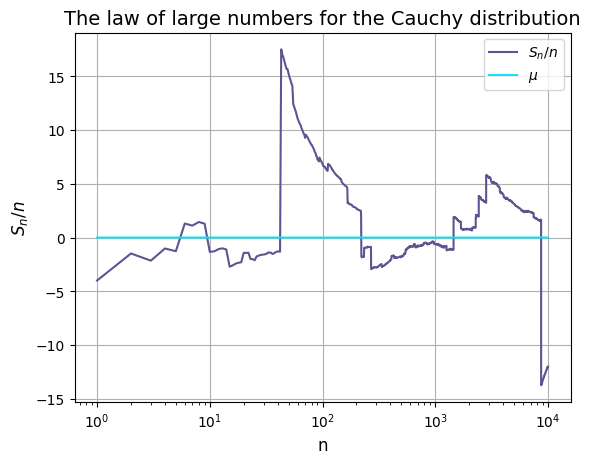

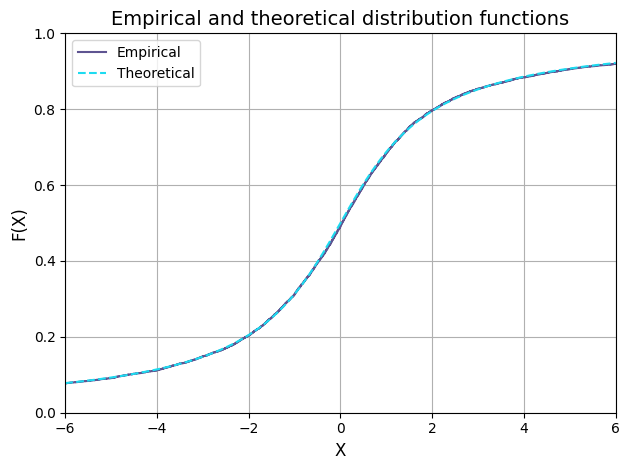

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

def cochi(x0, gamma, n, m):
    u = np.random.rand(n, m)
    return x0 + gamma * np.tan(np.pi * (u - 0.5))

def cochi_formula(a, b, x):
    return np.arctan((x - a)/b)/np.pi + 0.5

# Параметры
a = 0
b = 1.5
num = 10000
x_left = -10
x_right = 10

# S_n/n
n = np.linspace(1, num, num)
sns = cochi(a, b, 1, num)
sns = np.cumsum(sns)
plt.figure()
plt.semilogx(n, sns/n, color = '#5E5491',markersize=1, label='$S_n/n$')
plt.semilogx(n, np.zeros_like(n), '#1ddbf0', label='$\mu$')
plt.xlabel('n')
plt.ylabel('$S_n/n$')
plt.legend()
plt.grid(True)
plt.title('The law of large numbers for the Cauchy distribution')

# Эмпирическая и теоретическая CDF
plt.figure()
new_res = np.zeros(num)
for i in range(num):
    new_res[i] = np.sum(cochi(a, b, 1, num)) / num
ecdf = ECDF(new_res)
x_ecdf = np.linspace(-6, 6, 1000)
y_ecdf = ecdf(x_ecdf)
plt.step(x_ecdf, y_ecdf, where='post', color = '#5E5491', label='Empirical')
x = np.linspace(x_left, x_right, num)
y = cochi_formula(a, b, x)
plt.plot(x, y, '#1ddbf0', linestyle = '--', label='Theoretical')
plt.xlabel('X')
plt.ylabel('F(X)')
plt.xlim([-6, 6])
plt.ylim([0, 1])
plt.legend(fontsize=10)
plt.grid(True)
plt.title('Empirical and theoretical distribution functions')
plt.show()

# **Задание 6**
*   Вычислить следующий интеграл: $$\int_{-\infty}^{\infty} \int_{-\infty}^{\infty} \dots \int_{-\infty}^{\infty} \frac{e^{-\left(x_1^2 + \dots + x_{10}^2 + \frac{1}{2^7 \cdot x_1^2 \dots x_{10}^2}\right)}}{x_1^2 \dots x_{10}^2} \, dx_1 \, dx_2 \dots dx_{10}
$$
1.   Методом Монте-Карло.
2.   Методом квадратур, сводя задачу к вычислению собственного интеграла
Римана.
*    Оценить точность вычислений для каждого из двух случаев.





---

**Метод Монте-Карло**

Рассмотрим многомерный интеграл:

$$
\int\limits_{-\infty}^{\infty} \int\limits_{-\infty}^{\infty} \cdots \int\limits_{-\infty}^{\infty}
e^{-\left(x_1^2 + \ldots + x_{10}^2 + \frac{1}{2^7 \cdot x_1^2\cdot \ldots\cdot x_{10}^2}\right)}
dx_1 \ldots dx_{10}
$$

Представим его в виде:

$$
\int\limits_{-\infty}^{\infty} \int\limits_{-\infty}^{\infty} \cdots \int\limits_{-\infty}^{\infty} f(x_1, ..., x_{10})g(x_1, ..., x_{10}) dx_1...dx_{10},
$$

где:

\begin{align*}
f(x_1, ..., x_{10}) = \sqrt{\pi^{10}} \cdot \frac{e^{-\frac{1}{2^7 \cdot x_1\cdot ...\cdot x_{10}}}}{x_1\cdot ...\cdot x_{10}}, \\
g(x_1, ..., x_{10}) &= \frac{1}{\sqrt{\pi^{10}}} \cdot e^{\left(x_1^2+...+x^2_{10}\right)}.
\end{align*}

Заметим, что $g(x)$ является совместной плотностью распределения независимых случайных величин с нормальным распределением $\mathcal{N}\left(0,\frac{1}{2}\right)$:

$$
x = (x_1, x_{10}), ~~~x_i \sim \mathcal{N}\left(0,\frac{1}{2}\right), \quad i=1,\ldots,10.
$$

Тогда исходный интеграл можно выразить как:

$$
I = \mathbb{E}f(x_1, ..., x_{10}), \quad x_i \sim \mathcal{N}\left(0,\frac{1}{2}\right).
$$

Для оценки интеграла методом Монте-Карло генерируем выборку:

$$
\mathbf{x}^i = (x_1^i,\ldots,x_{10}^i), \quad x_k^i \sim \mathcal{N}\left(0,\frac{1}{2}\right), \quad k=1,\ldots,10, \quad i=1,\ldots,n.
$$

Согласно закону больших чисел, выборочное среднее сходится к искомому интегралу:

$$
\bar{f} = \frac{S_n}{n} =  \frac{1}{n}\sum_{i=1}^n f(x^i) \xrightarrow[n\to\infty]{} I .
$$

Оценим погрешность метода Монте-Карло с помощью центральной предельной теоремы:
$$\mathbb{P}\left(\left|\frac{S_n}{n} - I\right| < \varepsilon\right) = \mathbb{P}\left(\left|\frac{S_n - nI}{n}\right| < \varepsilon\right) = \mathbb{P}\left(\left|\frac{S_n - nI}{\sigma\sqrt{n}}\right| < \frac{\sqrt{n}}{\sigma}\varepsilon\right) = \mathbb{P}\left(-\frac{\sqrt{n}}{\sigma} \varepsilon < \frac{S_n - nI}{\sigma\sqrt{n}} < \frac{\sqrt{n}}{\sigma}\varepsilon\right) = \Phi_0\left(\frac{\sqrt{n}}{\sigma}\varepsilon\right) - \Phi_0\left(-\frac{\sqrt{n}}{\sigma}\varepsilon\right) = \Phi_0\left(\frac{\sqrt{n}}{\sigma}\varepsilon\right) - \left(1 - \Phi_0\left(\frac{\sqrt{n}}{\sigma}\varepsilon\right)\right) = 1 - 2\Phi_0\left(\frac{\sqrt{n}}{\sigma}\varepsilon\right) = 1 - 2\Phi_0(x_p) = \alpha,$$
где

* $\Phi_0(x)$ — функция Лапласа (функция ошибок):
$$
\Phi_0(x) = \frac{1}{\sqrt{2\pi}} \int_{0}^{x} e^{-t^2/2} dt
$$

* $x_p=\frac{\sqrt{n}}{\sigma}\varepsilon$ — квантиль уровня $p$, то есть решение уравнения:
$$
\Phi_0(x_p) = p
$$

* $\alpha$ — уровень доверия

Погрешность $\varepsilon$ для соответствующего уровня доверия $\alpha = 1 - 2\Phi_0(x_p)$ связана с $x_p$ соотношением:
$$
\varepsilon = \frac{\sigma x_p}{\sqrt{n}}
$$

Значение $\sigma > 0$ — выборочное стандартное отклонение:
$$
\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^n f^2(x_i) - \left( \frac{1}{n} \sum_{i=1}^n f(x_i) \right)^2}
$$

Для уровня доверия $\alpha = 0.95$ имеем:
$$
P\left( \left| \frac{S_n}{n} - I \right| < \varepsilon \right) = \alpha = 0.95
$$

In [64]:
import numpy as np
import scipy.stats as stats
import time

# Параметры
alpha = 0.05
n = 10**7

# Функция g(x)
def g(x):
    return (np.pi**5) * np.exp(-1.0 / (2**7 * np.prod(x**2, axis=0))) / np.prod(x**2, axis=0)

# Время начала выполнения
start_time = time.time()

# Генерируем случайные числа
x = (1/np.sqrt(2)) * np.random.randn(10, n)

# Вычисление интеграла
g_values = g(x)
integral = np.mean(g_values)

# Вычисление накопленных сумм
s = np.cumsum(g_values) / np.arange(1, n+1)

# Вычисление дисперсии
s1 = np.cumsum(g_values**2)
s2 = np.cumsum(g_values)
d = s1[1:] / np.arange(1, n) - (np.arange(2, n+1) * (s[1:]**2)) / np.arange(1, n)

# Вычисление доверительного интервала
epsilon = stats.norm.ppf(1 - alpha/2) * np.sqrt(d) / np.sqrt(np.arange(1, n))

# Время окончания выполнения
end_time = time.time()

# Выводим результаты
print(f"Значение интеграла: {integral}")
print(f"Предельная ошибка: {epsilon[-1]}")
print(f"Время выполнения: {end_time - start_time:.2f} секунд")

Значение интеграла: 125.08916774188836
Предельная ошибка: 0.707113766281105
Время выполнения: 5.85 секунд




---

**Метод квадратур**

Сведём задачу к вычислению собственного интеграла Римана. Для этого выполним замену переменных:

$$
x_i = tg\left( \frac{\pi}{2} t_i \right), \quad t_i \in [0, 1].
$$

Применяя метод прямоугольников, приблизим исходный интеграл выражением:

$$
I \approx \left( \frac{\pi}{2} \right)^{10} \int_{-1}^{1} \cdots \int_{-1}^{1}
\dfrac{e^{ -\left( \sum\limits_{k=1}^{10} tg^2\left( \frac{\pi}{2} t_k \right) + \frac{1}{2^7 \prod\limits_{k=1}^{10} tg^2\left( \frac{\pi}{2} t_k \right)} \right)}}{ \prod\limits_{k=1}^{10} tg^2\left( \frac{\pi}{2} t_k \right)\cdot\prod\limits_{k=1}^{10}\cos^2\left( \frac{\pi}{2} t_k \right)} dt_1 \ldots dt_{10}.
$$

Проведём равномерное разбиение отрезка $[0, 1]$ на $N$ частей:

$$
-1 = t_0 < t_1 < \cdots < t_N = 1, \quad t_i = -1 +i \cdot \frac{1-(-1)}{N}=i\frac{2}{N}-1.
$$

Обозначим подынтегральную функцию как $f(t_1, \ldots, t_{10})$. Используем метод средних прямоугольников, выбрав середины подынтервалов:

$$
y_i = \frac{t_i + t_{i-1}}{2}, \quad i=1,\ldots,N.
$$

Тогда приближённое значение интеграла:

$$
I_N = \left( \frac{\pi}{N} \right)^{10} \sum_{i_1=1}^{N} \cdots \sum_{i_{10}=1}^{N} f(y_{i_1}, \ldots, y_{i_{10}}).
$$

Оценка погрешности метода прямоугольников:

$$
\varepsilon = \frac{h^2}{24} (b-a)\sum_{i,j=1}^{10} \max \left| \frac{\partial^2 f}{\partial t_i \partial t_j} \right| = \frac{1}{6N^2} \sum_{i,j=1}^{10} \max \left| \frac{\partial^2 f}{\partial t_i \partial t_j} \right|,
$$
где $h = 1/N$ — шаг разбиения.


In [76]:
import numpy as np
import time
from itertools import product

def F(x):
    tan_terms = np.sum(np.tan(np.pi/2 * x)**2)
    cot_terms = 1/128 * np.prod(1/np.tan(np.pi/2 * x)**2)
    denominator = np.prod(np.sin(np.pi/2 * x)**2)
    return (np.pi**10) * np.exp(-(tan_terms + cot_terms)) / denominator

# Начало
start_time = time.time()

# Параметры
N = 10
K = 6
delta = (K-1)**(-N)
x_k = np.linspace(0, 1, K) + 1/(2*(K-1))
x_k = x_k[:-1]  # Удаляем последний элемент
S = 0.0

# Генерируем все возможные комбинации индексов
for indices in product(range(K-1), repeat=N):
    x = np.array([x_k[i] for i in indices])
    S += F(x)
integral = S * delta

# Конец
end_time = time.time()

# Выводим результаты
print(f"integral = {integral}")
print(f"Время выполнения: {end_time - start_time:.2f} секунд")

integral = 116.39025860065173
Время выполнения: 300.97 секунд


Вывод: метод Монте–Карло работает намного эффективнее по скорости, чем метод
квадратур.
